In [2]:
%pip install os
import os as os
os.environ['PYTHONHASHSEED'] = '42' #setting random seed for reprodcuibility during assesment
os.environ['TF_DETERMINISTIC_OPS'] = '1' #setting random seed for reprodcuibility during assesment

ERROR: Could not find a version that satisfies the requirement os (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for os
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install numpy "tensorflow==2.16.1" "protobuf>=4.23,<5.0"

import numpy as np
import tensorflow as tf
import random as rn
#Setting random seeds for reproducibility during assessment, there are 4 libraries used in this code that use random seeds, so we set them all to the same value for consistency. this is as per Keras documentation. 

tf.random.set_seed(42) #setting random seed for reprodcuibility during assesment
np.random.seed(42) #setting random seed for reprodcuibility during assesment
rn.seed(42) #setting random seed for reprodcuibility during assesment



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install pandas scikit-learn matplotlib keras pydot rn visualkeras==0.1.1
import pandas as pd
from sklearn.linear_model import LinearRegression #for polynomial regression
from sklearn.preprocessing import PolynomialFeatures #for polyonomial regression
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib import pyplot as plt
from tensorflow import keras
import tensorflow as tf
import os
import random as rn
import visualkeras



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


2026-04-30 13:53:19.370579: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-30 13:53:19.389722: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-30 13:53:19.611566: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-30 13:53:21.010303: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-30 13:53:23.748358: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF

****1. Loading & exploring the Data set**** + 2. Preparing trainign and validation data

In [4]:
train_data = pd.read_csv('train.csv')
validation_data = pd.read_csv('val.csv')


In [5]:
#identifying features and target variable
X_train = train_data.drop('y', axis=1) #feature for training
y_train = train_data['y'] #target variable for training

X_val = validation_data.drop('y', axis=1) #x feature for validation
y_val = validation_data['y'] #target variable for validation


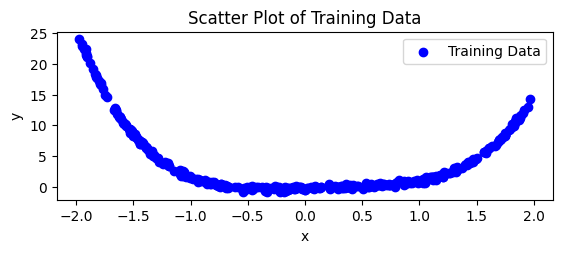

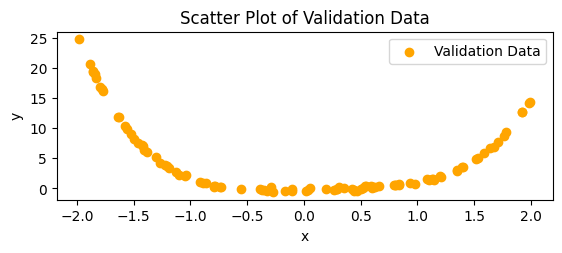

In [6]:
plt.subplot(2,1,1)
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of Training Data')
plt.legend()
plt.show()

plt.subplot(2,1,2)
plt.scatter(X_val, y_val, color='orange', label='Validation Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of Validation Data')
plt.legend()
plt.show()


***Interpretation***
- the data above is plotted for the training and validation set
- the input variable is x and the output variable is y
- It forms a structure similar to a polynomial regression with degree 2

****3. Implementing the baseline least squares****

In [7]:
#polynomial regression
degree = 4 #degree of the polynomial
poly_features = PolynomialFeatures(degree=degree)
X_train_poly_four = poly_features.fit_transform(X_train) #transforming the training data to include
#polynomial features
X_val_poly = poly_features.transform(X_val) #transforming the validation data to include polynomial
#features
poly_model = LinearRegression() #creating a linear regression model
poly_model.fit(X_train_poly_four, y_train) #fitting the model to the training data
y_val_pred_poly = poly_model.predict(X_val_poly) #predicting the target variable for
#validation data
mse_poly = mean_squared_error(y_val, y_val_pred_poly) #calculating mean squared error for polynomial regression
r2_poly = r2_score(y_val, y_val_pred_poly) #calculating R-squared score for polynomial regression
print(f'Polynomial Regression (degree={degree}): MSE={mse_poly}, R2={r2_poly}')
print(f'Polynomial Regression Coefficients: {poly_model.coef_}, Intercept: {poly_model.intercept_}')


Polynomial Regression (degree=4): MSE=0.03073080806923643, R2=0.9991388369981277
Polynomial Regression Coefficients: [ 0.          0.50759346  0.28989804 -0.80366203  1.20539343], Intercept: -0.21463817306569632


In [8]:
coefficients = poly_model.coef_

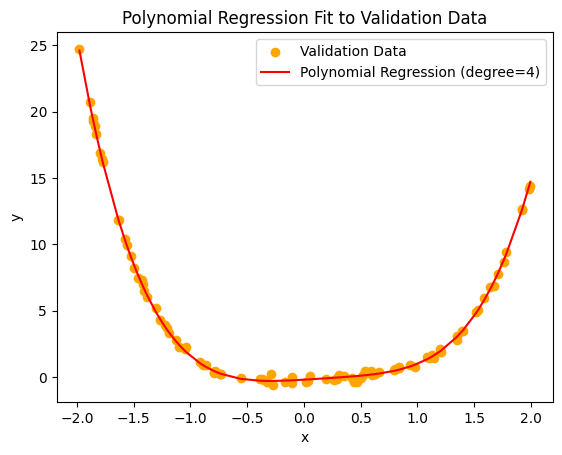

In [9]:
#graphing our polynomial regression and validation data together
plt.scatter(X_val, y_val, color='orange', label='Validation Data')
X_val_sorted = np.sort(X_val.values.flatten()) #sorting the x values for a smoother
#constructing the polynomial equation
x = X_val_sorted.flatten()

y = coefficients[1]*x**1 + coefficients[2]*x**2 + coefficients[3]*x**3 + coefficients[4]*x**4 + poly_model.intercept_
#variable for the sorted x values
plt.plot(X_val_sorted, y, color='red', label=f'Polynomial Regression (degree={degree})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Polynomial Regression Fit to Validation Data')
plt.show()



****4. Neural network, Tensorflow implementation****

In [10]:
#Model architecture: Keras and tensorflow
tf.keras.backend.clear_session() #clearing any previous models from memory to avoid clutter and potential issues with model reuse


tf.random.set_seed(42)
np.random.seed(42)
rn.seed(42)
model = tf.keras.Sequential()

#layer 1 & 2: input layer with 32 neurons and ReLU activation function
model.add(tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(tf.keras.layers.Dense(32, activation='relu'))
#layer 2: output layer with 1 neuron (for regression) and no activation function
model.add(tf.keras.layers.Dense(1, ))

model.summary()




/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#model plotting
nn_architecture = visualkeras.graph_view(model = model)
nn_architecture.show()


AttributeError: 'Node' object has no attribute 'inbound_layers'

In [ ]:
#Compling the model
model.compile(optimizer='sgd', loss='mean_squared_error', metrics= [tf.keras.metrics.R2Score()])

#training the model
history_nn = model.fit(X_train, y_train, epochs=300, batch_size=32, validation_data=(X_val, y_val)) #keras does not using validation data for training, it only uses it to evaluate the model after each epoch


****4.1 Monitoring training behavior during optimization: Stochastic gradient descent****

In [ ]:
#retrieve the training history - Loss values for each epoch
train_loss = history_nn.history['loss']
val_loss = history_nn.history['val_loss']

#retrieve the training history - MSE for each epoch
#plotting the training and validation loss
plt.figure(figsize=(20, 10))
plt.plot(train_loss, label='Training MSE')
plt.plot(val_loss, label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Training and Validation MSE')
plt.legend()
plt.show()


****4.2 Monitoring Training behavior: Polynomial Regression.**** 

In [ ]:
#plotting the training and validation R2 score for polynomial regression
y_train_pred_poly = poly_model.predict(X_train_poly_four) #predicting the target variable JUST TO SEE THE MSE GAP
mse_poly_train = mean_squared_error(y_train_pred_poly, y_train)


plt.bar(height = mse_poly_train, x='Training MSE')
plt.bar(height = mse_poly, x='Validation MSE')
plt.ylabel('MSE')
plt.title('Training and Validation MSE for polynomial model')
plt.legend()
plt.show()


****5. Evaluating model performance: Polynomial regression vs neural network****

In [ ]:
#model predictions on validation data
y_val_pred_keras = model.predict(X_val) 
nn_mse_test = mean_squared_error(y_val, y_val_pred_keras) #computing prediction error for neural network regression
nn_r2_test = r2_score(y_val, y_val_pred_keras) #calculating R-squared score for neural network regression
print(f'Neural Network Regression: MSE={nn_mse_test:.4f}, R2={nn_r2_test:.4f}')
#plotting the predicted vs actual values for validation data - nn mode
plt.figure(figsize=(12, 6))
plt.scatter(X_val, y_val, color='blue', label='Actual Values')
plt.scatter(X_val, y_val_pred_keras, color='orange', label='Predicted Values')
plt.xlabel('x_val')
plt.ylabel('y_val')
plt.title('Actual vs Predicted Values (Keras Model)')
plt.legend()
plt.show()



In [ ]:
#visualizing the predictions of both models
plt.figure(figsize=(12, 6))
plt.scatter(X_val, y_val, color='blue', label='Actual Values')
plt.scatter(X_val, y_val_pred_poly, color='orange', label='Polynomial Regression Predictions')
plt.title('Actual vs Predicted Values (Polynomial Regression)')
plt.xlabel('X_val')
plt.ylabel('y_val')
plt.legend()
plt.show()

In [ ]:
#comparing the metrics of both models
plt.figure(figsize=(12, 6))
plt.bar(['Polynomial Regression', 'Neural Network'], [mse_poly, nn_mse_test], color=['orange', 'blue'])
plt.ylabel('Mean Squared Error')
plt.title('Comparison of MSE for Polynomial Regression and Neural Network')
plt.show()

In [ ]:
#comparing the metrics r2 score of both models
plt.figure(figsize=(12, 6))
plt.bar(['Polynomial Regression', 'Neural Network'], [r2_poly, nn_r2_test], color=['orange', 'blue'])
plt.ylabel('R2 Score')
plt.title('Comparison of R2 Score for Polynomial Regression and Neural Network')
plt.show()